# RDD

In [399]:
!pip install -r requirements.txt

### Import données

In [400]:
import importlib
import credentials
importlib.reload(credentials)
import os 
import pandas as pd
from BDTopo_fonctions import load_gpkg

#vote
remote_path="Elections/donnees_duel_maires_wide.csv"
local_path = f"/tmp/{os.path.basename(remote_path)}"
credentials.s3.download_file("mgarbe", remote_path, local_path)
df_vote=pd.read_csv(local_path, sep=",")
df_vote=df_vote[['id_election','rang1_Nuance','rang2_Nuance','rang1_voix_pct','rang2_voix_pct','election',
'tour','annee','dep_x','Nuance_interco','Code INSEE','Code Postal']].copy()
#code nuances politiques
remote_path="Elections/nuances.csv"
local_path = f"/tmp/{os.path.basename(remote_path)}"
credentials.s3.download_file("mgarbe", remote_path, local_path)
nuances=pd.read_csv(local_path, sep=",")

#données geo
gdf=load_gpkg("Sitadel/df_clustering_fulldep_1000m3.gpkg") #SANS CLUSTER !!!
gdf=gdf[gdf["Base"]=="Sitadel"].copy()

Téléchargement depuis mgarbe/Sitadel/df_clustering_fulldep_1000m3.gpkg ...
Chargement réussi (324979 lignes)


In [401]:
df_vote

,id_election,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour,annee,dep_x,Nuance_interco,Code INSEE,Code Postal
0,2014_muni_t2,LDVD,LDVG,61.309524,21.726190,2014_muni,t2,2014,01,NC,01004,01500
1,2014_muni_t1,LDIV,NaN,100.000000,NaN,2014_muni,t1,2014,01,LDVD,01005,01330
2,2014_muni_t2,LDVG,LDVD,46.779141,41.487730,2014_muni,t2,2014,01,NC,01007,01500
3,2014_muni_t1,LDVD,LDVD,56.153846,43.846154,2014_muni,t1,2014,01,NC,01010,01350
4,2014_muni_t1,LUMP,NaN,100.000000,NaN,2014_muni,t1,2014,01,LDVD,01014,01100
...,...,...,...,...,...,...,...,...,...,...,...,...
12258,2020_muni_t1,LDVD,LUG,58.329564,36.016885,2020_muni,t1,2020,95,LDVD,95607,95150
12259,2020_muni_t2,LDVD,LDVG,48.525214,35.680304,2020_muni,t2,2020,95,LDVD,95612,95500
12260,2020_muni_t1,LDVG,LDVC,51.761583,39.623552,2020_muni,t1,2020,95,LDVG,95637,95490
12261,2020_muni_t2,LDVD,LDVC,73.375796,26.624204,2020_muni,t2,2020,95,NC,95652,95270


In [402]:
nuance_dict = pd.Series(nuances['Code'].values, index=nuances['Nuance']).to_dict()
df_vote['rang1_Nuance'] = df_vote['rang1_Nuance'].map(nuance_dict)
df_vote['rang2_Nuance'] = df_vote['rang2_Nuance'].map(nuance_dict)
df_vote['Nuance_interco'] = df_vote['Nuance_interco'].map(nuance_dict)

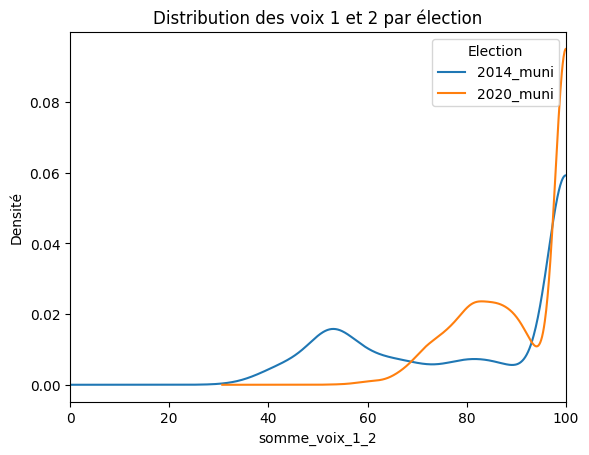

In [403]:
import matplotlib.pyplot as plt
for c, g in df_vote.groupby("election"):
    (g["rang1_voix_pct"] + g["rang2_voix_pct"]).dropna().plot(
        kind="kde",
        label=str(c)
    )
plt.xlabel("somme_voix_1_2")
plt.ylabel("Densité")
plt.xlim(0, 100)
plt.title("Distribution des voix 1 et 2 par élection")
plt.legend(title="Election")
plt.show()

In [404]:
df_vote.groupby(["election","rang1_Nuance"]).size()

election   rang1_Nuance
2014_muni  -1.0            2935
            0.0            1652
            1.0            4631
2020_muni  -1.0             947
            0.0             411
            1.0            1686
dtype: int64

In [405]:
df_vote = df_vote[
    (df_vote["rang1_Nuance"].abs() == 1) &
    (df_vote["rang2_Nuance"].abs() == 1) &
    (df_vote["rang1_Nuance"] != df_vote["rang2_Nuance"])
].copy()
#df_vote = df_vote[(df_vote['voix_pct'] > 50) & (df_vote['voix_pct'] < 100)].copy() #hors triangulaires, 2 candidats
df_vote['delta_score_1'] = df_vote['rang1_Nuance'] * (df_vote['rang1_voix_pct'] - df_vote['rang2_voix_pct'])
df_vote["duel"] = ((df_vote["rang1_voix_pct"] + df_vote["rang2_voix_pct"]) == 100).astype(int)



In [406]:
#on réduit aux communes dans la fenêtre du RDD
seuil=8 #seul-2 au niveau d'un duel, dans le cas d'une triangulaire on fait l'hp d'un transfert parfait
df_vote.groupby(["election", "duel"])["delta_score_1"].apply(lambda x: (abs(x) < seuil).sum())

election   duel
2014_muni  0        91
           1       252
2020_muni  0       103
           1        95
Name: delta_score_1, dtype: int64

In [407]:
df_vote_seuil=df_vote[abs(df_vote["delta_score_1"])<seuil].copy()
df_vote_seuil=df_vote_seuil[["election","Code INSEE","rang1_Nuance","delta_score_1","Nuance_interco"]]

In [408]:
id_communes=df_vote_seuil.groupby("election")["Code INSEE"].unique()

In [409]:
import geopandas as gpd

# Fonction pour créer la colonne mandat_elec
def assign_mandat(annee):
    if 2014 <= annee <= 2019:
        return 2014  # groupe 1
    elif 2020 <= annee <= 2025:
        return 2020  # groupe 2
    else:
        return None   # pour filtrer les années hors des plages

# Création de la colonne
gdf['mandat_elec'] = gdf['Annee_REF'].apply(assign_mandat)

# Filtrage uniquement sur les périodes souhaitées
gdf = gdf[gdf['mandat_elec'].notna()].copy()

In [410]:
# Normaliser COMM à 5 caractères
gdf['COMM'] = gdf['COMM'].astype(str)
gdf.loc[gdf['COMM'].str.len() == 4, 'COMM'] = '0' + gdf.loc[gdf['COMM'].str.len() == 4, 'COMM']

#Summary par commune (ie. une ligne == une commune)
gdf_summary = gdf.groupby(["mandat_elec", "COMM"]).agg(
    nb_permis=("SURF_CREEE", "count"),           # nombre de permis / lignes
    surface_creee=("SURF_CREEE", "sum"),        # somme de la surface créée
    surface_moyenne=("SURF_CREEE", "mean")     # surface moyenne par permis
).reset_index()

gdf_summary['mandat_elec'] = gdf_summary['mandat_elec'].astype(str) + '_muni'

In [411]:

# Filtrer par mandat_elec et id_communes correspondantes
gdf_RDD_list = []

for mandat in id_communes.index:
    communes = [str(c).zfill(5) for c in id_communes[mandat]]  # s'assure que 5 chiffres
    gdf_RDD_list.append(
        gdf_summary[(gdf_summary['mandat_elec'] == mandat) & (gdf_summary['COMM'].isin(communes))]
    )

# Concaténer les deux groupes
gdf_RDD = pd.concat(gdf_RDD_list, ignore_index=True)

In [412]:
# Assure que les colonnes sont bien des strings
gdf_RDD['COMM'] = gdf_RDD['COMM'].astype(str)
df_vote_seuil['Code INSEE'] = df_vote_seuil['Code INSEE'].astype(str)

# Merge : toutes les lignes de df_vote sont conservées
df_merged = df_vote_seuil.merge(
    gdf_RDD,
    left_on=['Code INSEE', 'election'],
    right_on=['COMM', 'mandat_elec'],
    how='left'
)

cols_to_fill = ['nb_permis', 'surface_creee','surface_moyenne']  # adapte selon tes colonnes
df_merged[cols_to_fill] = df_merged[cols_to_fill].fillna(0)

# Supprimer la colonne redondante
df_merged = df_merged.drop(columns=['COMM', 'mandat_elec']).copy()
gdf_RDD=df_merged.copy()

## RESULTATS 

In [413]:
gdf_RDD.groupby(['election','rang1_Nuance'])['Code INSEE'].nunique().reset_index(name='nb_communes')

,election,rang1_Nuance,nb_communes
0,2014_muni,-1.0,157
1,2014_muni,1.0,186
2,2020_muni,-1.0,89
3,2020_muni,1.0,109


### RDD LINEAIRE

In [414]:
gdf_RDD.columns

Index(['election', 'Code INSEE', 'rang1_Nuance', 'delta_score_1',
       'Nuance_interco', 'nb_permis', 'surface_creee', 'surface_moyenne'],
      dtype='object')

                            OLS Regression Results                            
Dep. Variable:        surface_moyenne   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.460
Date:                Fri, 30 Jan 2026   Prob (F-statistic):              0.234
Time:                        11:57:50   Log-Likelihood:                -3315.1
No. Observations:                 343   AIC:                             6636.
Df Residuals:                     340   BIC:                             6648.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      2432.6387    458.528      5.305

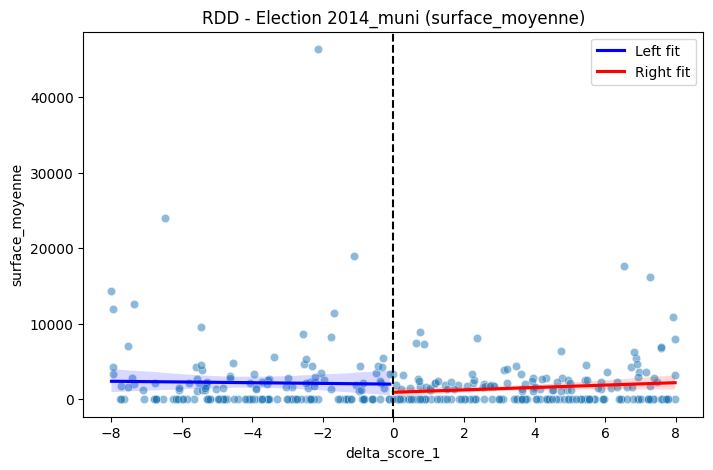

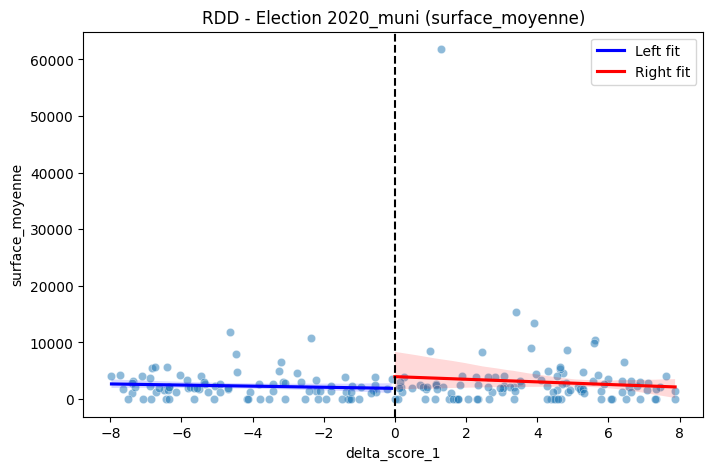

In [415]:
from RDD_functions import compute_rdd, plot_rdd

var='surface_moyenne'
print(compute_rdd(gdf_RDD, outcome_var=var)["2014_muni"])

plot_rdd(gdf_RDD, outcome_var=var)